# Análise de Dados de Commodities Agrícolas

Este projeto tem como objetivo analisar dados de produção/valor da soja no Brasil, utilizando dados do IBGE para identificar tendências ao longo do tempo.

## Importação de bibliotecas

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Adiciona a pasta raiz ao sistema para o Python encontrar a pasta 'src'
sys.path.append(os.path.abspath('..'))

from src.utils import limpar_valor_ibge

## Carregamento dos dados

In [10]:
# Pulamos a primeira linha (skiprows=1) pois o título real está na segunda
df = pd.read_csv('../data/soja_ibge.csv', 
                 encoding='latin-1', 
                 sep=',', 
                 skiprows=1,
                 decimal='.')

# Visualizar se carregou certo
df.head()

,localidade,valor,unidade
0,Serra Nova Dourada - MT,115.576,Mil Reais
1,SÃ£o FÃ©lix do Araguaia - MT,2.096.471,Mil Reais
2,RibeirÃ£o Cascalheira - MT,495.706,Mil Reais
3,Novo Santo AntÃ´nio - MT,10.595,Mil Reais
4,Nova NazarÃ© - MT,105.600,Mil Reais


## Exploração dos dados

In [11]:
df.columns
df.head()

,localidade,valor,unidade
0,Serra Nova Dourada - MT,115.576,Mil Reais
1,SÃ£o FÃ©lix do Araguaia - MT,2.096.471,Mil Reais
2,RibeirÃ£o Cascalheira - MT,495.706,Mil Reais
3,Novo Santo AntÃ´nio - MT,10.595,Mil Reais
4,Nova NazarÃ© - MT,105.600,Mil Reais


Os dados brutos contêm caracteres especiais e formatos de moeda brasileira. Nesta etapa, realizamos o casting para float para permitir cálculos matemáticos.

In [12]:
# Usando a função que criei na pasta src
df = limpar_valor_ibge(df, 'valor')

# Verifica o resultado
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   localidade  142 non-null    object 
 1   valor       141 non-null    float64
 2   unidade     141 non-null    object 
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


## 4. Análise dos Maiores Produtores
Nesta seção, identificamos os municípios de Mato Grosso com maior valor de produção de soja.

In [13]:
# Seleciona as 10 cidades com maior valor
top_10 = df.nlargest(10, 'valor')

# Exibe o resultado de forma organizada
print("Top 10 Municípios Produtores (MT):")
print(top_10[['localidade', 'valor']])

Top 10 Municípios Produtores (MT):
                       localidade      valor
109                  Sorriso - MT  3331063.0
74             Nova UbiratÃ£ - MT  2395288.0
1    SÃ£o FÃ©lix do Araguaia - MT  2096471.0
72                Nova Mutum - MT  1881000.0
92                QuerÃªncia - MT  1869600.0
29     Campo Novo do Parecis - MT  1846051.0
107                  Sapezal - MT  1843169.0
79               Paranatinga - MT  1737002.0
44                Diamantino - MT  1661083.0
91        Primavera do Leste - MT  1613557.0


# Criando um gráfico de barras para o Top 10

Abaixo, geramos um gráfico de barras para visualizar o Top 10. Note que o município de Sorriso lidera com folga o valor de produção.

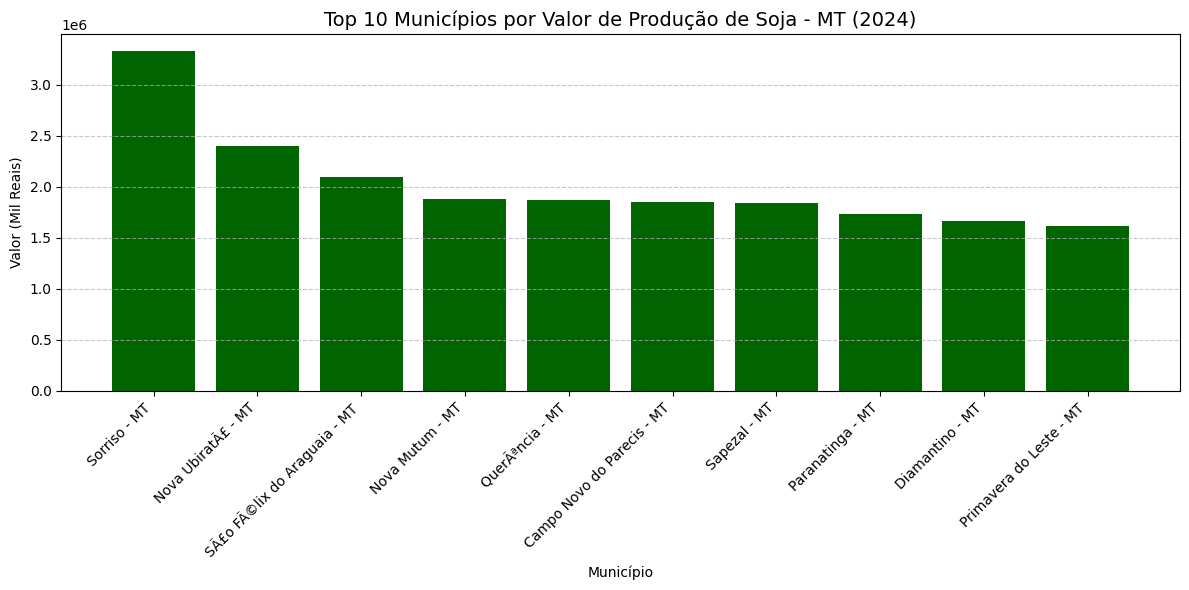

In [16]:
plt.figure(figsize=(12, 6))
plt.bar(top_10['localidade'], top_10['valor'], color='darkgreen')

plt.title('Top 10 Municípios por Valor de Produção de Soja - MT (2024)', fontsize=14)
plt.xlabel('Município')
plt.ylabel('Valor (Mil Reais)')
plt.xticks(rotation=45, ha='right') # Rotaciona os nomes para não embolar
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../grafico_producao_soja.png', dpi=300, bbox_inches='tight')
plt.show()